### Advanced Crystallographic Analysis of h-BN and Silicon

In [1]:
from pymatgen.core import Structure
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

from ase.io import read
from ase.visualize import view


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
## loading dataset

hbn = Structure.from_file("..\\data\\h-BN.cif")

si = Structure.from_file("..\\data\\sillicon.cif")

c:\Users\Admin\anaconda3\Lib\site-packages\pymatgen\core\structure.py:3112: UserWarning: Issues encountered while parsing CIF: 2 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]


In [3]:
## Supercells

hbn_super = hbn.copy()

hbn_super.make_supercell([2, 2, 1])

# [2,2,1] means repeat the first two dimensions twice and the third dimension once

print(hbn_super)

Full Formula (B8 N8)
Reduced Formula: BN
abc   :   5.020000   5.020000   6.690000
angles:  90.000000  90.000000 120.000000
pbc   :       True       True       True
Sites (16)
  #  SP           a         b     c
---  ----  --------  --------  ----
  0  B3+   0.166667  0.333333  0.05
  1  B3+   0.166667  0.833333  0.05
  2  B3+   0.666667  0.333333  0.05
  3  B3+   0.666667  0.833333  0.05
  4  B3+   0.333333  0.166667  0.95
  5  B3+   0.333333  0.666667  0.95
  6  B3+   0.833333  0.166667  0.95
  7  B3+   0.833333  0.666667  0.95
  8  N3-   0         0         0
  9  N3-   0         0.5       0
 10  N3-   0.5       0         0
 11  N3-   0.5       0.5       0
 12  N3-   0         0         0.5
 13  N3-   0         0.5       0.5
 14  N3-   0.5       0         0.5
 15  N3-   0.5       0.5       0.5


In [4]:
## Silicon supercell

si_super = si.copy()

si_super.make_supercell([2, 2, 2])

# [2,2,2] means repeat all three dimensions twice

print(si_super)

Full Formula (Si64)
Reduced Formula: Si
abc   :  10.861400  10.861400  10.861400
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (64)
  #  SP        a      b      c
---  ----  -----  -----  -----
  0  Si    0      0      0
  1  Si    0      0      0.5
  2  Si    0      0.5    0
  3  Si    0      0.5    0.5
  4  Si    0.5    0      0
  5  Si    0.5    0      0.5
  6  Si    0.5    0.5    0
  7  Si    0.5    0.5    0.5
  8  Si    0      0.25   0.25
  9  Si    0      0.25   0.75
 10  Si    0      0.75   0.25
 11  Si    0      0.75   0.75
 12  Si    0.5    0.25   0.25
 13  Si    0.5    0.25   0.75
 14  Si    0.5    0.75   0.25
 15  Si    0.5    0.75   0.75
 16  Si    0.25   0      0.25
 17  Si    0.25   0      0.75
 18  Si    0.25   0.5    0.25
 19  Si    0.25   0.5    0.75
 20  Si    0.75   0      0.25
 21  Si    0.75   0      0.75
 22  Si    0.75   0.5    0.25
 23  Si    0.75   0.5    0.75
 24  Si    0.25   0.25   0
 25  Si    0.25   0.25   0.5
 26 

In [5]:
## Visualization supercell
###  Convert to Ase atoms

from pymatgen.io.ase import AseAtomsAdaptor

adaptor = AseAtomsAdaptor()

hbn_ase = adaptor.get_atoms(hbn_super)

si_ase = adaptor.get_atoms(si_super)

In [6]:
## Visualize h-BN supercell


view(hbn_ase)

<Popen: returncode: None args: ['c:\\Users\\Admin\\anaconda3\\python.exe', '...>

In [7]:
## Visualization of Si Supercell

view(si_ase)

<Popen: returncode: None args: ['c:\\Users\\Admin\\anaconda3\\python.exe', '...>

# Crystal Symmetry Analysis

Crystal symmetry describes repeating geometric operations that leave a crystal unchanged.

Symmetry analysis is fundamental in:
- crystallography
- solid state physics
- diffraction analysis
- electronic structure calculations

Important symmetry properties include:
- space group
- crystal system
- point group

In [8]:
## Space Group Analysis

hbn_sg = SpacegroupAnalyzer(hbn)

si_sg = SpacegroupAnalyzer(si)


print("h-BN Space Group:")
print(hbn_sg.get_space_group_symbol())


print("\nSi Space Group:")
print(si_sg.get_space_group_symbol())

h-BN Space Group:
P-3m1

Si Space Group:
Fd-3m


In [9]:
## Get Crystal System

print("h-BN Crystal System:")
print(hbn_sg.get_crystal_system())

print("\nSi Crystal System:")
print(si_sg.get_crystal_system())

h-BN Crystal System:
trigonal

Si Crystal System:
cubic


In [10]:
## Get Point Groups

print('h-BN Point Group: ')
print(hbn_sg.get_point_group_symbol())


print('\nSi Point Group: ')
print(si_sg.get_point_group_symbol())

h-BN Point Group: 
-3m

Si Point Group: 
m-3m


# Primitive and Conventional Cells

A primitive cell contains the minimum number of atoms required to represent crystal periodicity.

A conventional cell is often chosen to emphasize crystal symmetry.

Comparing primitive and conventional cells helps understand:
- symmetry representation
- lattice geometry
- structural simplification

In [11]:
## Get primitive structure

hbn_primitive = hbn.get_primitive_structure()

si_primitive = si.get_primitive_structure()

print("h-BN Primitive Structure:")
print(hbn_primitive)


print("\n\n")


print("\nSi Primitive Structure:")
print(si_primitive)

h-BN Primitive Structure:
Full Formula (B2 N2)
Reduced Formula: BN
abc   :   2.510000   2.510000   6.690000
angles:  90.000000  90.000000 120.000000
pbc   :       True       True       True
Sites (4)
  #  SP           a         b     c
---  ----  --------  --------  ----
  0  B3+   0.333333  0.666667  0.05
  1  B3+   0.666667  0.333333  0.95
  2  N3-   0         0         0
  3  N3-   0         0         0.5




Si Primitive Structure:
Full Formula (Si2)
Reduced Formula: Si
abc   :   3.840085   3.840085   3.840085
angles:  60.000000  60.000000  60.000000
pbc   :       True       True       True
Sites (2)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Si    0     0     0
  1  Si    0.75  0.75  0.75


# Periodic Crystal Geometry

Crystalline materials exhibit long-range periodic atomic ordering.

Supercell visualization demonstrates:
- translational symmetry
- repeating atomic motifs
- crystal dimensionality
- extended bonding networks

In [12]:
## lattice vector analysis

print("h-BN Lattice Vectors:")
print(hbn.lattice.matrix)

print("\nSi Lattice Vectors:")
print(si.lattice.matrix)

h-BN Lattice Vectors:
[[ 2.51000000e+00  0.00000000e+00  1.53693173e-16]
 [-1.25500000e+00  2.17372376e+00  1.53693173e-16]
 [ 0.00000000e+00  0.00000000e+00  6.69000000e+00]]

Si Lattice Vectors:
[[5.43070000e+00 0.00000000e+00 3.32534469e-16]
 [8.73323167e-16 5.43070000e+00 3.32534469e-16]
 [0.00000000e+00 0.00000000e+00 5.43070000e+00]]


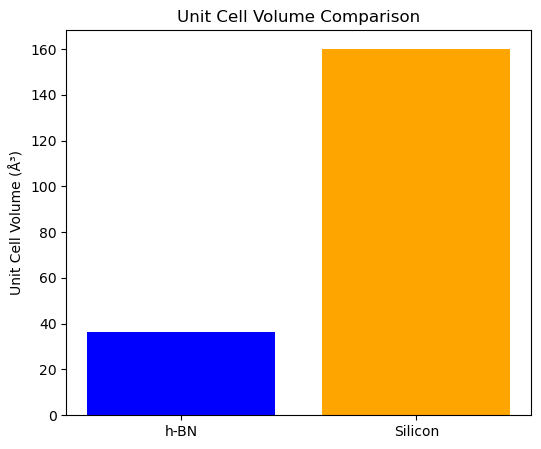

In [13]:
## Unit cell volume 

materials = ["h-BN", "Silicon"]

volumes = [hbn.lattice.volume, si.lattice.volume]


plt.figure(figsize=(6,5))
plt.bar(materials, volumes, color=['blue', 'orange'])
plt.ylabel('Unit Cell Volume (Å³)')
plt.title('Unit Cell Volume Comparison')
plt.show()

# Interpretation

The crystallographic analyses reveal major structural differences between h-BN and Silicon.

h-BN demonstrates layered trigonal symmetry with planar coordination and anisotropic geometry.

Silicon exhibits highly symmetric cubic geometry with three-dimensional tetrahedral bonding.

The supercell analysis further illustrates crystal periodicity and extended atomic arrangement.

In [14]:
summary = {
    "Property": [
        "Crystal System",
        "Space Group",
        "Point Group",
        "Density",
        "Volume"
    ],

    "h-BN": [
        hbn_sg.get_crystal_system(),
        hbn_sg.get_space_group_symbol(),
        hbn_sg.get_point_group_symbol(),
        hbn.density,
        hbn.lattice.volume
    ],

    "Silicon": [
        si_sg.get_crystal_system(),
        si_sg.get_space_group_symbol(),
        si_sg.get_point_group_symbol(),
        si.density,
        si.lattice.volume
    ]
}

summary_df = pd.DataFrame(summary)

summary_df

,Property,h-BN,Silicon
0,Crystal System,trigonal,cubic
1,Space Group,P-3m1,Fd-3m
2,Point Group,-3m,m-3m
3,Density,2.258065,2.329452
4,Volume,36.500952,160.164933
